# Balanced Model Testing

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("logs/WednesdayTraffic_cleaned.csv")
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print(df.head())

Dataset shape: (1031018, 80)
Duplicate rows: 0
   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0        80         6  2018-02-21 08:33:25          37953             5   
1       500        17  2018-02-21 08:33:06      117573474             3   
2       500        17  2018-02-21 08:33:11       99743998             5   
3       500        17  2018-02-21 08:33:11       99743999             5   
4       500        17  2018-02-21 08:33:08       89479580             6   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             3              135              127              135   
1             0             1500                0              500   
2             0             2500                0              500   
3             0             2500                0              500   
4             0             3000                0              500   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0          

In [3]:
X = df.drop("Label", axis=1)
y = df["Label"]

print(X.shape)
print(y.shape)

X.dtypes

(1031018, 79)
(1031018,)


Dst Port           int64
Protocol           int64
Timestamp            str
Flow Duration      int64
Tot Fwd Pkts       int64
                  ...   
Active Min         int64
Idle Mean        float64
Idle Std         float64
Idle Max           int64
Idle Min           int64
Length: 79, dtype: object

We still have Timestamp as a str, which isn't great. For now we will test a couple of models dropping the Timestamp Column, since it is generally not that important for the model we are trying to create. However we will test it again later.

In [4]:
df = df.drop("Timestamp", axis=1)

X = df.drop("Label", axis=1)
y = df["Label"]

X.columns

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

In [5]:
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (1031018, 78)
Label shape: (1031018,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Training set: (824814, 78)
Test set: (206204, 78)

Training label distribution:
Label
1    536153
0    288661
Name: count, dtype: int64

Test label distribution:
Label
1    134038
0     72166
Name: count, dtype: int64


In [7]:
# combine training features and labels
train_df = pd.concat([X_train, y_train], axis=1)

# separate classes
attack = train_df[train_df["Label"] == 1]
benign = train_df[train_df["Label"] == 0]

print("Original class counts:")
print(train_df["Label"].value_counts())

Original class counts:
Label
1    536153
0    288661
Name: count, dtype: int64


In [8]:
attack_downsampled = resample(
    attack,
    replace=False,
    n_samples=len(benign),
    random_state=42
)

balanced_train = pd.concat([attack_downsampled, benign])

In [9]:
X_train_bal = balanced_train.drop("Label", axis=1)
y_train_bal = balanced_train["Label"]

print("Balanced training distribution:")
print(y_train_bal.value_counts())

Balanced training distribution:
Label
1    288661
0    288661
Name: count, dtype: int64


# Logistic Regression

In [10]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_bal, y_train_bal)

log_pred = log_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, log_pred))

Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



Suspiciously perfect, may be a sign of data leakage. Lets confirm it isn't overfitting and tests its performance against the test dataset.

In [11]:
train_pred = log_model.predict(X_train_bal)
print("Training performance")
print(classification_report(y_train_bal, train_pred))

Training performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288661
           1       1.00      1.00      1.00    288661

    accuracy                           1.00    577322
   macro avg       1.00      1.00      1.00    577322
weighted avg       1.00      1.00      1.00    577322



In [12]:
# make predictions on the test data
y_pred = log_model.predict(X_test)

# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# full evaluation report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9999951504335512

Confusion Matrix:
[[ 72165      1]
 [     0 134038]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



It seems to be a 

# Decision Tree Model

In [13]:
tree_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

tree_model.fit(X_train_bal, y_train_bal)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [14]:
tree_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

importance = pd.Series(tree_model.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False).head(10))

Accuracy: 1.0

Confusion Matrix:
[[ 72166      0]
 [     0 134038]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204

Tot Fwd Pkts         0.992975
Subflow Fwd Byts     0.005093
Init Fwd Win Byts    0.001800
Fwd IAT Min          0.000125
Dst Port             0.000007
Protocol             0.000000
TotLen Bwd Pkts      0.000000
Fwd Pkt Len Max      0.000000
Fwd Pkt Len Min      0.000000
Fwd Pkt Len Mean     0.000000
dtype: float64


Looking at what the decision tree is doing, it seems that one feature alone is what is deciding the model decision. This is due to DDoS traffic often sending huge numbers of packets in one direction when an attack is occuring. I suppose if you really think about it, its not like its difficult to detect when a DDoS attack is occuring in general.

In [15]:
#just to test if there is any data leakage

train_pred = tree_model.predict(X_train_bal)

print(classification_report(y_train_bal, train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288661
           1       1.00      1.00      1.00    288661

    accuracy                           1.00    577322
   macro avg       1.00      1.00      1.00    577322
weighted avg       1.00      1.00      1.00    577322



# Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_bal, y_train_bal)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 72166      0]
 [     0 134038]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



Subflow Fwd Pkts     0.104650
Fwd Header Len       0.101273
Dst Port             0.101082
TotLen Fwd Pkts      0.083473
Tot Fwd Pkts         0.081518
Fwd Pkt Len Max      0.066291
Subflow Fwd Byts     0.064583
Fwd Pkt Len Mean     0.059465
Init Bwd Win Byts    0.054358
Fwd Pkt Len Std      0.044454
dtype: float64


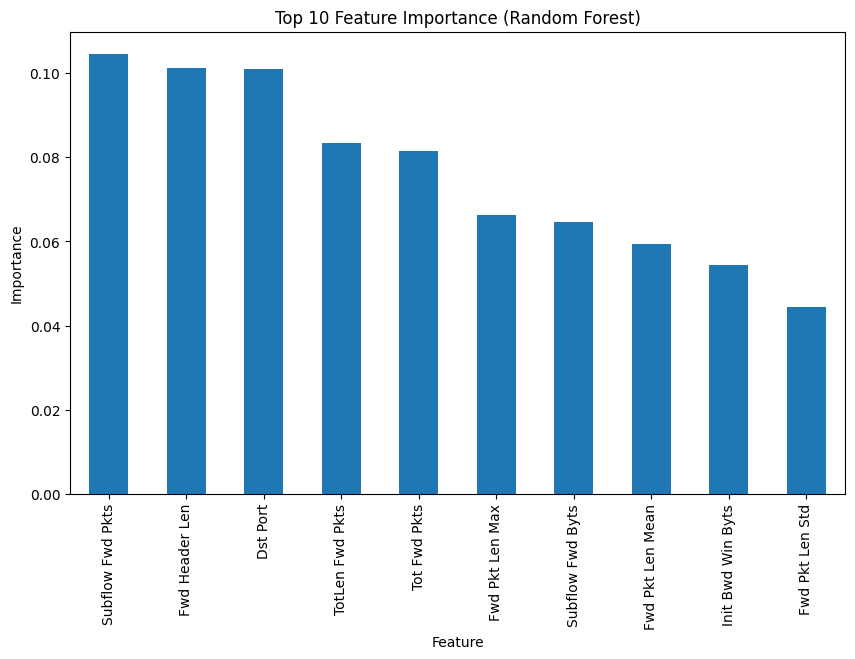

In [17]:
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False).head(10))


importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

In [18]:
scores = cross_val_score(
    rf_model,
    X_train_bal,
    y_train_bal,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation scores:", scores)
print("Average F1 score:", np.mean(scores))

Cross-validation scores: [1. 1. 1. 1. 1.]
Average F1 score: 1.0


Lets do an interesting experiment, where we will test performance to ensure there is no leakage. If we shuffle the labels and the model collapses to about 50%, the pipeline will be correct.

In [19]:
y_shuffled = np.random.permutation(y_train_bal)

rf_shuffle = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_shuffle.fit(X_train_bal, y_shuffled)

shuffle_pred = rf_shuffle.predict(X_test)

print("Accuracy:", accuracy_score(y_test, shuffle_pred))
print(classification_report(y_test, shuffle_pred))

Accuracy: 0.5641646136835367
              precision    recall  f1-score   support

           0       0.40      0.52      0.45     72166
           1       0.69      0.59      0.64    134038

    accuracy                           0.56    206204
   macro avg       0.55      0.55      0.55    206204
weighted avg       0.59      0.56      0.57    206204



Considering the results is showcases that the model is learning actual patterns from the data, so when there is shuffling of training labels, model performance drops, closer to random guessing.